<a href="https://colab.research.google.com/github/Smarth2005/UCS761-Deep-Learning/blob/main/Lab-2%20Logisitic%20Regression%20using%20Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Lab Exercise-2
### Logistic regression: Implement single layer perceptron for glass classification.

Link for dataset: https://www.kaggle.com/datasets/uciml/glass

Reference link: [Open Me](https://medium.com/analytics-vidhya/logistic-regression-using-single-layer-perceptron-neural-network-slpnn-31757c792d5d)

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving glass.csv to glass.csv


In [ ]:
df = pd.read_csv("glass.csv")
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [ ]:
df.shape

(214, 10)

In [ ]:
df["Type"].unique()

array([1, 2, 3, 5, 6, 7])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


There are no missing values in the dataset.

In [ ]:
# glass_type 1, 2, 3, 4 are window glass captured as "1"
# glass_type 5, 6, 7 are non-window glass captured as "0"

df['Window'] = df.Type.map({1:1, 2:1, 3:1, 4:1, 5:0, 6:0, 7:0})

In [ ]:
df['Window'].head()

,Window
0,1
1,1
2,1
3,1
4,1


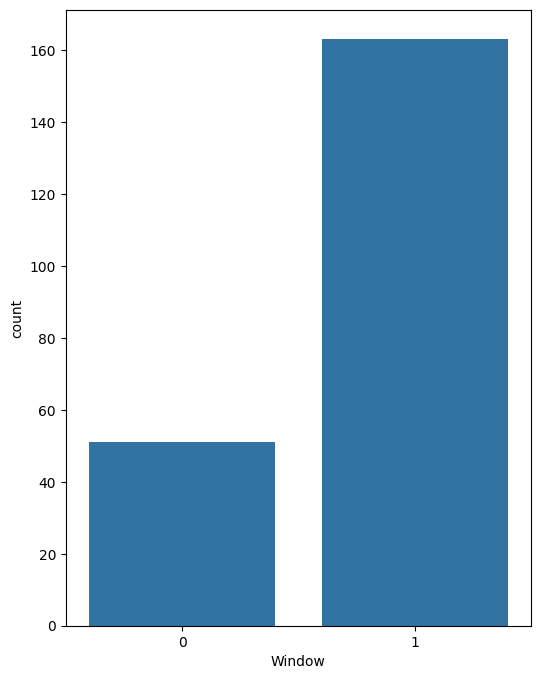

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 8))
sns.countplot(x=df["Window"])
plt.show()


In [ ]:
df["Window"].value_counts()

,count
Window,
1,163
0,51


The value counts indicate an imbalance class distribution.Since our goal is to implement a single-layer perceptron using logistic regression, we would handle class imbalance using class weighting instead of resampling. This avoids synthetic data generation and preserves the original data distribution.

In [ ]:
df = df.drop("Type", axis=1)

array([[<Axes: title={'center': 'RI'}>, <Axes: title={'center': 'Na'}>,
        <Axes: title={'center': 'Mg'}>],
       [<Axes: title={'center': 'Al'}>, <Axes: title={'center': 'Si'}>,
        <Axes: title={'center': 'K'}>],
       [<Axes: title={'center': 'Ca'}>, <Axes: title={'center': 'Ba'}>,
        <Axes: title={'center': 'Fe'}>]], dtype=object)

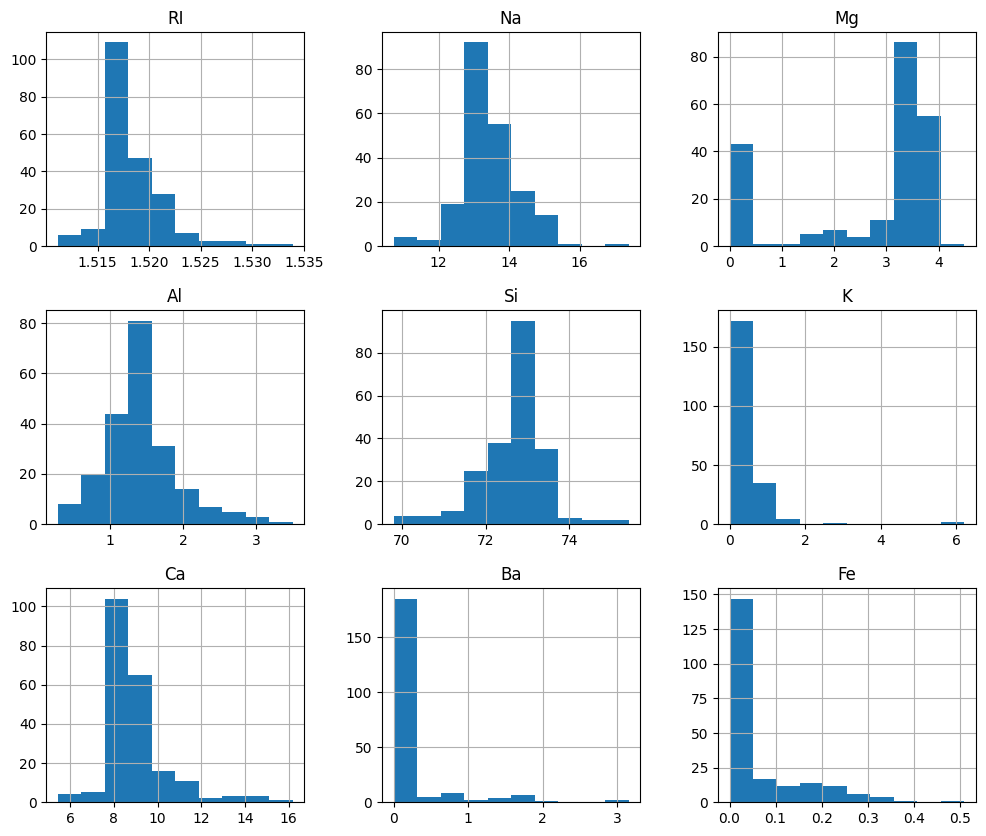

In [ ]:
# Checking feature distribution
df.drop('Window', axis=1).hist(figsize=(12, 10))

Overall features are roughly bell-shaped and slightly skewed. Hence, feature scaling is mandatory.

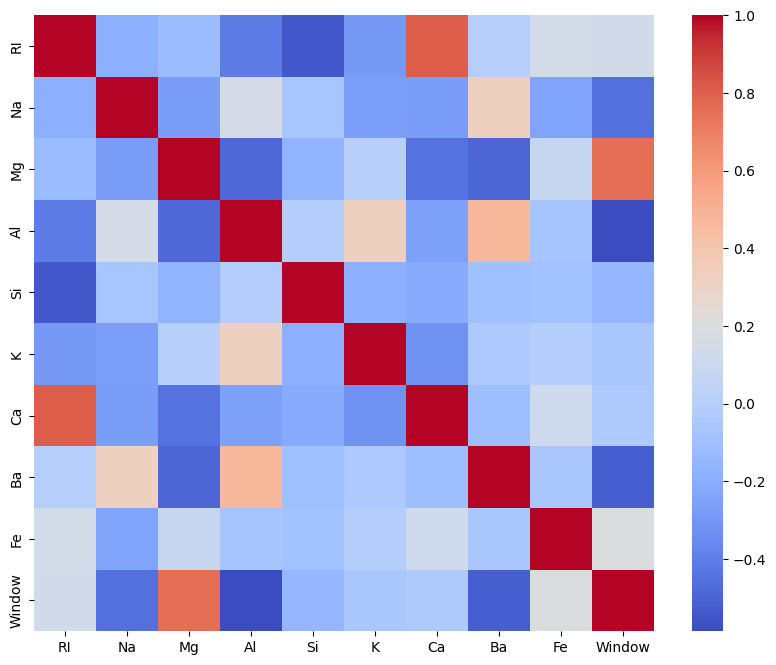

In [ ]:
# Correlation Analysis
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.show()

In [ ]:
# Separate X and y
X = df.drop('Window', axis=1)
y = df['Window']

In [ ]:
# feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
class LogisticRegressionSinglePerceptronModel:

    def __init__(self, eta, inputLayer, outputLayer):
        self.eta = eta
        self.inputLayer = inputLayer
        self.outputLayer = outputLayer
        self.w = np.zeros((inputLayer, 1))
        self.E = np.array([])
        self.w_list = []

    def sigmoid(self, x):
        x = np.clip(x, -500, 500)
        return 1 / (1 + np.exp(-x))

    def feedforward(self, X):
        z = np.dot(X, self.w)
        return self.sigmoid(z)

    def error(self, h, y):
        eps = 1e-9
        h = np.clip(h, eps, 1 - eps)
        err = (-y * np.log(h) - (1 - y) * np.log(1 - h)).mean()
        self.E = np.append(self.E, err)

    def backprop(self, X, y, h):
        grad = np.dot(X.T, (h - y)) / X.shape[0]
        self.w_list.append(self.w.copy())
        self.w = self.w - self.eta * grad

    def predict(self, X):
        return self.feedforward(X)

    def classify(self, X):
        return (self.predict(X) >= 0.5).astype(int)

    def train(self, X, y):
       X = np.array(X)
       y = np.array(y).reshape(-1, 1)

       for epoch in range(epochs):
          h = self.feedforward(X)
          self.backprop(X, y, h)
          self.error(h, y)

    def plot(self):
      plt.figure(figsize=(6,4))
      plt.plot(self.E)
      plt.xlabel("Epochs")
      plt.ylabel("Error")
      plt.title("Training Error Curve")
      plt.grid(True)
      plt.show()


CPU times: user 1 s, sys: 2.72 ms, total: 1 s
Wall time: 1.04 s


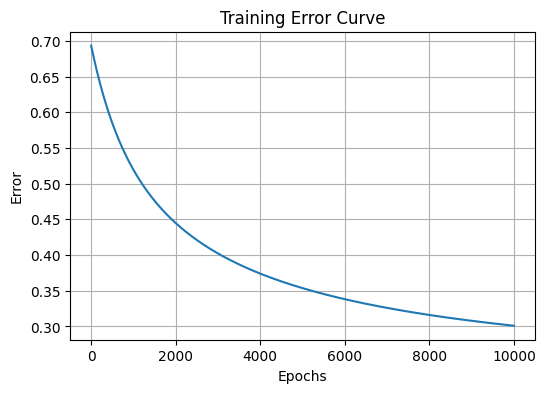

Minimum Error achieved: 0.3009362977151233


array([[ 0.05734481],
       [-0.65386617],
       [ 1.13405646],
       [-0.84856487],
       [-0.25644209],
       [-0.07041457],
       [-0.14389319],
       [-0.57558944],
       [ 0.19784412]])

In [ ]:
# Learning Rate
eta = 0.001
epochs = 10000
inputLayer = X.shape[1]
outputLayer = 1

SPNN = LogisticRegressionSinglePerceptronModel(eta, inputLayer, outputLayer)

%time SPNN.train(X_train, y_train)

SPNN.plot()

pred = SPNN.predict(X_test)
pred2 = SPNN.classify(X_test)

print("Minimum Error achieved:", min(SPNN.E))
SPNN.w


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# y_test ko bhi column → flat
y_test_np = np.array(y_test).reshape(-1, 1)

acc = accuracy_score(y_test_np, pred2)
print("Accuracy:", acc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_np, pred2))

print("\nClassification Report:")
print(classification_report(y_test_np, pred2))


Accuracy: 0.9302325581395349

Confusion Matrix:
[[10  0]
 [ 3 30]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      1.00      0.87        10
           1       1.00      0.91      0.95        33

    accuracy                           0.93        43
   macro avg       0.88      0.95      0.91        43
weighted avg       0.95      0.93      0.93        43



Result Summary:
- Model: Single Layer Perceptron (Logistic Regression)
- Activation Function: Sigmoid
- Loss Function: Cross Entropy
- Learning Rate: 0.001
- Epochs: 10,000
- Accuracy Achieved: 93%
